25Hz PPG가 200Hz PPG가 가진 ‘혈압 관련 정보(beat morphology)를 얼마나 보존하는지’와, 그 정보가 ABPM 혈압과 얼마나 연관되는지(=BP 추정 가능성의 프록시)를 동시에 점검하는 평가 파이프라인

Analysis Start


/tmp/ipython-input-2271877501.py:165: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dt_try = pd.to_datetime(df[c], errors="coerce")


[ABPM] 93 events (2025-09-13 01:30:00 ~ 2025-09-14 22:00:00)
[Watch] shape=(5599248, 2), ppg_col=1 (Time: 2025-09-13 01:24:00 base)
[Ring] shape=(144000, 10), ppg_col=ppg (Time: 2025-09-13 01:24:00 base)

[Common Period] 2025-09-13 01:30:00 ~ 2025-09-13 09:00:02.328000

[Beats] Watch: 29418, Ring: 5889

[Result: Correlation Ring vs Watch]
  HR_mean: n=15, r=0.906
  AMP_mean: n=15, r=-0.306


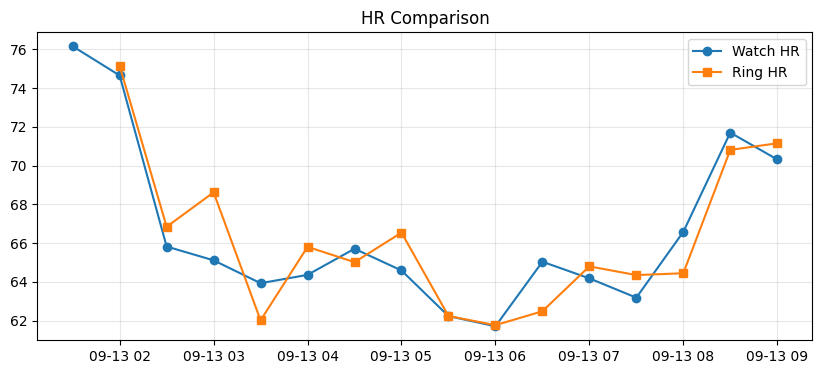

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, detrend, find_peaks

# ============================================================
# CONFIG
# ============================================================
RAW_PPG_200_CSV = "/content/drive/MyDrive/Colab Notebooks/RealPPG/ppgRaw2.csv"
FS_200 = 200.0
PPG_200_START_TIME = "2025-09-13 01:24:00"

PPG_25_CSV = "/content/drive/MyDrive/Colab Notebooks/RealPPG/E0001_2.csv"
FS_25 = 25.0
PPG_25_START_TIME = "2025-09-13 01:24:00"

ABPM_XLSX = "/content/drive/MyDrive/Colab Notebooks/PPG_REAL/PWV1.xlsx"

MIN_BPM = 40
MAX_BPM = 200
PROM_SCALE_200 = 0.2
PROM_SCALE_25 = 0.1
ABPM_WIN_MIN = 10
MIN_BEATS_IN_WIN = 10

# ============================================================
# FUNCTIONS
# ============================================================

def read_csv_robust(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    def is_numberish(x):
        try:
            float(str(x).strip())
            return True
        except: return False
    if df.shape[1] >= 2 and all(is_numberish(c) for c in df.columns):
        df = pd.read_csv(path, header=None)
    return df

def pick_time_col(df: pd.DataFrame) -> str:
    cand = ["timestamp", "Timestamp", "time", "Time", "sample_or_time", "sample_time", "t",
            "sample_index", "index", "Index"]
    for c in cand:
        if c in df.columns: return c
    return df.columns[0]

def infer_ppg_col(df: pd.DataFrame, time_col: str) -> str:
    # [수정] 'acc', 'gyro', 'x', 'y', 'z' 등 모션 센서 데이터도 제외
    exclude_keywords = ['sleep', 'step', 'battery', 'quality', 'flag', 'stage',
                        'day', 'month', 'year', 'date', 'index', 'cnt', 'count',
                        'acc', 'gyro', 'motion', 'axis']

    candidates = []
    for c in df.columns:
        if c == time_col: continue
        if any(k in str(c).lower() for k in exclude_keywords): continue
        try:
            pd.to_numeric(df[c])
            candidates.append(c)
        except: pass

    num_cols = [c for c in candidates if pd.api.types.is_numeric_dtype(df[c])]

    # 제외 키워드로 다 걸러지면, 최후의 수단으로 전체 숫자 컬럼 중 검색
    if len(num_cols) == 0:
        num_cols = [c for c in df.columns if c != time_col and pd.api.types.is_numeric_dtype(df[c])]

    if len(num_cols) == 0:
        if df.shape[1] == 2: return df.columns[1]
        raise ValueError(f"PPG 컬럼 추정 실패. 컬럼명: {df.columns.tolist()}")

    return num_cols[-1]

def build_datetime_smart(df: pd.DataFrame, time_col: str, fs: float, start_time: str) -> pd.Series:
    ts = pd.to_numeric(df[time_col], errors="coerce").to_numpy(dtype=float)
    ts = np.asarray(ts, dtype=float)
    valid_ts = ts[np.isfinite(ts)]
    if len(valid_ts) < 100: return None

    diffs = np.diff(valid_ts[:min(1000, len(valid_ts))])
    diffs = diffs[diffs > 0]

    unit, divisor = 's', 1.0
    if len(diffs) > 0:
        median_diff = np.median(diffs)
        if abs(median_diff - (1.0/fs)*1e6) < (1.0/fs)*1e6*0.5: unit, divisor = 'us', 1e6
        elif abs(median_diff - (1.0/fs)*1e3) < (1.0/fs)*1e3*0.5: unit, divisor = 'ms', 1e3
        elif abs(median_diff - (1.0/fs)) < (1.0/fs)*0.5: unit, divisor = 's', 1.0
        elif abs(median_diff - 1.0) < 0.5: unit, divisor = 'samples', fs
        else:
            if median_diff > 1000: unit, divisor = 'us', 1e6
            elif median_diff > 1: unit, divisor = 'ms', 1e3
            else: unit, divisor = 's', 1.0

    t_seconds = (ts - ts[0]) / divisor
    t_seconds = np.nan_to_num(t_seconds, nan=0.0)

    # 리턴을 무조건 Series로 보장
    dt = pd.to_datetime(start_time) + pd.to_timedelta(t_seconds, unit='s')
    return pd.Series(dt)

def preprocess_ppg(x: np.ndarray, fs: float) -> np.ndarray:
    if np.any(~np.isfinite(x)):
        x = pd.Series(x).interpolate(limit_direction="both").to_numpy(dtype=float)
    try:
        x0 = detrend(x)
        nyq = 0.5 * fs
        lo = max((MIN_BPM/60.0) / nyq, 1e-6)
        hi = min((MAX_BPM/60.0) / nyq, 0.999)
        b, a = butter(2 if fs < 50 else 4, [lo, hi], btype="band")
        return filtfilt(b, a, x0)
    except:
        return x - np.mean(x)

def extract_beat_features(dt: pd.Series, ppg: np.ndarray, fs: float, prom_scale: float) -> pd.DataFrame:
    y = preprocess_ppg(ppg, fs)
    t_sec = np.arange(len(y), dtype=float) / fs
    min_dist = int(round((60.0 / MAX_BPM) * fs))
    base_prom = prom_scale * np.nanstd(y)

    try:
        peaks, _ = find_peaks(y, distance=max(1, min_dist), prominence=base_prom)
        troughs, _ = find_peaks(-y, distance=max(1, min_dist), prominence=base_prom * 0.5)
    except: return pd.DataFrame(columns=["dt", "HR", "AMP", "RISE", "AREA"])

    if len(peaks) < 3 or len(troughs) < 3:
        return pd.DataFrame(columns=["dt", "HR", "AMP", "RISE", "AREA"])

    peaks = np.sort(peaks)
    troughs = np.sort(troughs)
    rows = []

    # dt가 Series인지 확인 (iloc 사용 위해)
    if not isinstance(dt, pd.Series):
        dt = pd.Series(dt)

    for j in range(len(troughs) - 1):
        iL, iR = troughs[j], troughs[j+1]
        if iR <= iL + 2: continue
        m = (peaks > iL) & (peaks < iR)
        if m.sum() == 0: continue
        iP = peaks[m][np.argmax(y[peaks[m]])]

        dt_beat = t_sec[iR] - t_sec[iL]
        if dt_beat <= 0: continue
        hr = 60.0 / dt_beat
        if not (MIN_BPM <= hr <= MAX_BPM): continue

        if pd.notna(dt.iloc[iP]):
            rows.append({
                "dt": dt.iloc[iP], "HR": hr,
                "AMP": y[iP] - y[iL], "RISE": t_sec[iP] - t_sec[iL],
                "AREA": np.trapezoid(y[iL:iR+1] - y[iL], t_sec[iL:iR+1])
            })
    return pd.DataFrame(rows)

def load_abpm_xlsx(path: str) -> pd.DataFrame:
    df = pd.read_excel(path)
    dt_col = None
    best_valid = -1

    # 2000년 이후 데이터만 유효한 것으로 간주 (1970년 제외)
    for c in df.columns:
        dt_try = pd.to_datetime(df[c], errors="coerce")
        valid_count = dt_try.notna().sum()
        if valid_count < 3: continue
        valid_years = dt_try.dt.year
        real_date_ratio = (valid_years >= 2000).sum() / valid_count
        if valid_count > best_valid and real_date_ratio > 0.5:
            best_valid = valid_count
            dt_col = c

    if dt_col is None:
        cols = list(df.columns)
        for c1 in cols:
            for c2 in cols:
                if c1 == c2: continue
                dt_try = pd.to_datetime(df[c1].astype(str) + " " + df[c2].astype(str), errors="coerce")
                valid_count = dt_try.notna().sum()
                if valid_count < 3: continue
                valid_years = dt_try.dt.year
                real_date_ratio = (valid_years >= 2000).sum() / valid_count
                if valid_count > best_valid and real_date_ratio > 0.5:
                    best_valid = valid_count
                    dt_col = (c1, c2)

    if isinstance(dt_col, tuple):
        dt = pd.to_datetime(df[dt_col[0]].astype(str) + " " + df[dt_col[1]].astype(str), errors="coerce")
    else:
        dt = pd.to_datetime(df[dt_col], errors="coerce")

    df["dt"] = dt
    df = df.dropna(subset=["dt"]).sort_values("dt").reset_index(drop=True)

    def pick(k):
        for c in df.columns:
            if k.lower() in str(c).lower(): return c
        return None
    mapping = {"SBP": pick("SBP") or pick("SYS"), "DBP": pick("DBP") or pick("DIA"), "MAP": pick("MAP")}
    out = df[["dt"] + [v for v in mapping.values() if v]].rename(columns={v:k for k,v in mapping.items()})
    for c in out.columns:
        if c != "dt": out[c] = pd.to_numeric(out[c], errors="coerce")
    return out

def load_ppg_wrapper(csv_path, fs, label, start, target_col=None):
    df = read_csv_robust(csv_path)
    time_col = pick_time_col(df)

    if target_col and target_col in df.columns:
        ppg_col = target_col
    elif target_col and target_col.isdigit():
        ppg_col = df.columns[int(target_col)]
    else:
        ppg_col = infer_ppg_col(df, time_col)

    print(f"[{label}] shape={df.shape}, ppg_col={ppg_col} (Time: {start} base)")
    dt = build_datetime_smart(df, time_col, fs, start)
    ppg = pd.to_numeric(df[ppg_col], errors="coerce").to_numpy(dtype=float)
    return dt, ppg

# ============================================================
# MAIN
# ============================================================
print("="*80)
print("Analysis Start")

# 1. Load Data
abpm = load_abpm_xlsx(ABPM_XLSX)
print(f"[ABPM] {len(abpm)} events ({abpm['dt'].min()} ~ {abpm['dt'].max()})")

dt_200, ppg_200 = load_ppg_wrapper(RAW_PPG_200_CSV, FS_200, "Watch", PPG_200_START_TIME, target_col="1")
dt_25, ppg_25 = load_ppg_wrapper(PPG_25_CSV, FS_25, "Ring", PPG_25_START_TIME)

# 2. Common Period
start = max(abpm['dt'].min(), dt_200.min(), dt_25.min())
end = min(abpm['dt'].max(), dt_200.max(), dt_25.max())
print(f"\n[Common Period] {start} ~ {end}")

if (end - start).total_seconds() <= 0:
    raise ValueError("시간대가 겹치지 않습니다. ABPM/Watch/Ring 시간 설정을 다시 확인해주세요.")

# 3. Cut & Analyze
m200 = (dt_200 >= start) & (dt_200 <= end)
m25 = (dt_25 >= start) & (dt_25 <= end)
mabpm = (abpm['dt'] >= start) & (abpm['dt'] <= end)

# [Fix] dt_200[m200]가 Index 객체일 경우 reset_index가 없으므로 Series로 변환 후 reset
dt2 = pd.Series(dt_200[m200]).reset_index(drop=True)
ppg2 = ppg_200[m200]

dt1 = pd.Series(dt_25[m25]).reset_index(drop=True)
ppg1 = ppg_25[m25]

abpm_cut = abpm[mabpm].reset_index(drop=True)

beats_200 = extract_beat_features(dt2, ppg2, FS_200, PROM_SCALE_200)
beats_25 = extract_beat_features(dt1, ppg1, FS_25, PROM_SCALE_25)
print(f"\n[Beats] Watch: {len(beats_200)}, Ring: {len(beats_25)}")

# 4. Feature Preservarion Check
def match_beats(beats, abpm_df):
    res = []
    for t in abpm_df["dt"]:
        # ABPM 시점 전후 10분 데이터 평균
        sub = beats[(beats["dt"] >= t - pd.Timedelta(minutes=10)) & (beats["dt"] <= t + pd.Timedelta(minutes=10))]
        if len(sub) < 10:
            res.append({k:np.nan for k in ["HR_mean","AMP_mean"]})
        else:
            res.append({"HR_mean": sub["HR"].mean(), "AMP_mean": sub["AMP"].mean()})
    return pd.DataFrame(res)

f200 = match_beats(beats_200, abpm_cut)
f25 = match_beats(beats_25, abpm_cut)

compare = pd.concat([abpm_cut,
                     f200.add_suffix("_200"),
                     f25.add_suffix("_25")], axis=1)

print("\n[Result: Correlation Ring vs Watch]")
for f in ["HR_mean", "AMP_mean"]:
    valid = compare[[f"{f}_200", f"{f}_25"]].dropna()
    if len(valid) > 2:
        r = np.corrcoef(valid[f"{f}_200"], valid[f"{f}_25"])[0,1]
        print(f"  {f}: n={len(valid)}, r={r:.3f}")
    else:
        print(f"  {f}: Not enough matched data (n={len(valid)})")

# Plot
fig, ax = plt.subplots(figsize=(10,4))
if "HR_mean_200" in compare.columns:
    ax.plot(compare["dt"], compare["HR_mean_200"], 'o-', label="Watch HR")
    ax.plot(compare["dt"], compare["HR_mean_25"], 's-', label="Ring HR")
    ax.set_title("HR Comparison")
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.show()


🚀 Advanced Analysis: Shape, PTT, and Windowing
Extracting Advanced Features...
  Watch Beats: 29418
  Ring Beats:  5889

[PTT Analysis: Watch -> Ring]
  Matched Beats for PTT: 5832
  Mean PTT: -7.62 ms (Positive means Ring is later)
  Std PTT:  271.81 ms


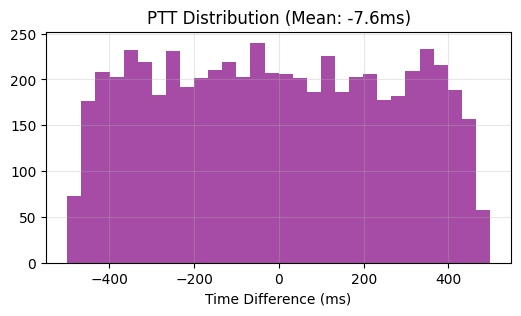


[Window Analysis: 5min]
  HR        : n=16, r=0.243
  NORM_AREA : n=16, r=-0.076
  SLOPE     : n=16, r=-0.466


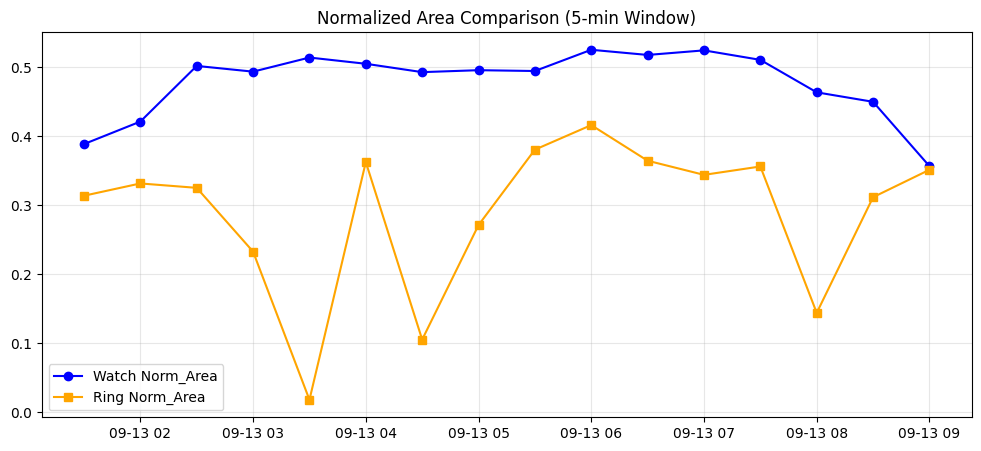


Analysis Complete. Check 'NORM_AREA' correlation for BP feasibility.


In [27]:
def extract_beat_features_advanced(dt: pd.Series, ppg: np.ndarray, fs: float, prom_scale: float) -> pd.DataFrame:
    # 기존 전처리 및 피크 검출 로직 동일
    y = preprocess_ppg(ppg, fs)
    t_sec = np.arange(len(y), dtype=float) / fs
    min_dist = int(round((60.0 / MAX_BPM) * fs))
    base_prom = prom_scale * np.nanstd(y)

    try:
        peaks, _ = find_peaks(y, distance=max(1, min_dist), prominence=base_prom)
        troughs, _ = find_peaks(-y, distance=max(1, min_dist), prominence=base_prom * 0.5)
    except: return pd.DataFrame()

    if len(peaks) < 3 or len(troughs) < 3: return pd.DataFrame()

    peaks = np.sort(peaks)
    troughs = np.sort(troughs)

    if not isinstance(dt, pd.Series): dt = pd.Series(dt)

    rows = []
    for j in range(len(troughs) - 1):
        iL, iR = troughs[j], troughs[j+1]
        if iR <= iL + 2: continue

        m = (peaks > iL) & (peaks < iR)
        if m.sum() == 0: continue
        iP = peaks[m][np.argmax(y[peaks[m]])]

        # 1. Basic Calculation
        dt_beat = t_sec[iR] - t_sec[iL] # Beat Duration
        if dt_beat <= 0: continue
        hr = 60.0 / dt_beat
        if not (MIN_BPM <= hr <= MAX_BPM): continue

        amp = y[iP] - y[iL]
        rise_time = t_sec[iP] - t_sec[iL]
        area = np.trapezoid(y[iL:iR+1] - y[iL], t_sec[iL:iR+1])

        # 2. Advanced Shape Features (Amplitude Independent)
        # 기울기 (상승 속도)
        slope = amp / rise_time if rise_time > 0 else np.nan
        # 정규화된 면적 (진폭 크기에 상관없는 파형의 뚱뚱함 정도)
        norm_area = area / amp if amp > 1e-6 else np.nan
        # 전체 폭 대비 상승 시간 비율 (대칭성)
        symmetry = rise_time / dt_beat

        if pd.notna(dt.iloc[iP]):
            rows.append({
                "dt": dt.iloc[iP],
                "HR": hr,
                "AMP": amp,
                "WIDTH": dt_beat,       # 박동 길이 (초)
                "RISE": rise_time,      # 상승 시간
                "SLOPE": slope,         # 상승 기울기
                "NORM_AREA": norm_area, # 정규화 면적 (중요)
                "SYM": symmetry         # 대칭성
            })

    return pd.DataFrame(rows)

def calculate_inter_device_ptt(watch_beats: pd.DataFrame, ring_beats: pd.DataFrame, max_diff_sec=0.5):
    """
    워치와 반지의 비트별 시간차(PTT) 계산
    가정: 두 기기의 절대 시간(Clock)이 동기화되어 있다고 가정
    """
    w_df = watch_beats.sort_values("dt").reset_index(drop=True)
    r_df = ring_beats.sort_values("dt").reset_index(drop=True)

    ptt_records = []

    # 워치 비트 하나하나에 대해 가장 가까운 반지 비트를 찾음
    # (워치가 상류, 반지가 하류이므로 워치 기준 탐색)
    for idx, row in w_df.iterrows():
        t_watch = row['dt']

        # 워치 시간 기준 앞뒤 max_diff_sec 내의 반지 비트 검색
        window_start = t_watch - pd.Timedelta(seconds=max_diff_sec)
        window_end = t_watch + pd.Timedelta(seconds=max_diff_sec)

        candidates = r_df[(r_df['dt'] >= window_start) & (r_df['dt'] <= window_end)]

        if len(candidates) > 0:
            # 가장 시간차이가 적은 것 선택
            candidates = candidates.copy()
            candidates['diff'] = (candidates['dt'] - t_watch).dt.total_seconds()

            # PTT = Ring - Watch (보통 양수, 손목->손가락)
            # 가장 가까운 매칭 선택
            best_match = candidates.loc[candidates['diff'].abs().idxmin()]

            ptt_val = best_match['diff'] * 1000.0 # ms 단위 변환

            ptt_records.append({
                "dt": t_watch,
                "PTT_ms": ptt_val,
                "Watch_HR": row['HR'],
                "Ring_HR": best_match['HR']
            })

    return pd.DataFrame(ptt_records)


def aggregate_windows(df: pd.DataFrame, window_size='1min') -> pd.DataFrame:
    """
    지정된 시간 윈도우(예: '1min', '5min') 단위로 평균값 계산
    """
    if df.empty: return pd.DataFrame()

    df = df.set_index('dt').sort_index()
    # 수치형 컬럼만 리샘플링
    resampled = df.resample(window_size).mean()

    # 데이터가 있는 구간만 남김 (NaN 제거)
    return resampled.dropna().reset_index()

def analyze_window_correlation(w_df, r_df, abpm_df, window='5min'):
    print(f"\n[Window Analysis: {window}]")

    # 1. 윈도우 단위 평균
    w_agg = aggregate_windows(w_df, window).add_suffix('_Watch')
    r_agg = aggregate_windows(r_df, window).add_suffix('_Ring')

    # 시간 컬럼 이름 복구
    w_agg = w_agg.rename(columns={'dt_Watch': 'dt'})
    r_agg = r_agg.rename(columns={'dt_Ring': 'dt'})

    # 2. Merge (Watch & Ring)
    merged = pd.merge_asof(w_agg.sort_values('dt'), r_agg.sort_values('dt'),
                           on='dt', tolerance=pd.Timedelta(window), direction='nearest')

    # 3. Merge with ABPM (ABPM 시간에 가장 가까운 윈도우 매칭)
    final = pd.merge_asof(abpm_df.sort_values('dt'), merged,
                          on='dt', tolerance=pd.Timedelta(minutes=10), direction='nearest')

    # 상관관계 출력
    cols = ['HR', 'NORM_AREA', 'SLOPE']
    for c in cols:
        cw = f"{c}_Watch"
        cr = f"{c}_Ring"
        if cw in final.columns and cr in final.columns:
            valid = final[[cw, cr]].dropna()
            if len(valid) > 2:
                r = np.corrcoef(valid[cw], valid[cr])[0,1]
                print(f"  {c:10s}: n={len(valid)}, r={r:.3f}")

    return final


# ============================================================
# NEW MAIN EXECUTION
# ============================================================
print("\n" + "="*80)
print("🚀 Advanced Analysis: Shape, PTT, and Windowing")
print("="*80)

# 1. Advanced Feature Extraction (형상 특징 포함)
#    (기존에 로드된 dt2, ppg2, dt1, ppg1 사용)
print("Extracting Advanced Features...")
beats_200_adv = extract_beat_features_advanced(dt2, ppg2, FS_200, PROM_SCALE_200)
beats_25_adv = extract_beat_features_advanced(dt1, ppg1, FS_25, PROM_SCALE_25)

print(f"  Watch Beats: {len(beats_200_adv)}")
print(f"  Ring Beats:  {len(beats_25_adv)}")

# 2. PTT Analysis (맥파 전달 시간)
print("\n[PTT Analysis: Watch -> Ring]")
if len(beats_200_adv) > 0 and len(beats_25_adv) > 0:
    ptt_df = calculate_inter_device_ptt(beats_200_adv, beats_25_adv)
    if len(ptt_df) > 0:
        mean_ptt = ptt_df['PTT_ms'].mean()
        std_ptt = ptt_df['PTT_ms'].std()
        print(f"  Matched Beats for PTT: {len(ptt_df)}")
        print(f"  Mean PTT: {mean_ptt:.2f} ms (Positive means Ring is later)")
        print(f"  Std PTT:  {std_ptt:.2f} ms")

        # PTT Histogram
        plt.figure(figsize=(6, 3))
        plt.hist(ptt_df['PTT_ms'], bins=30, color='purple', alpha=0.7)
        plt.title(f"PTT Distribution (Mean: {mean_ptt:.1f}ms)")
        plt.xlabel("Time Difference (ms)")
        plt.grid(True, alpha=0.3)
        plt.show()
    else:
        print("  No matched beats found for PTT calculation.")
else:
    print("  Not enough beats for PTT.")

# 3. Window Aggregation Analysis (윈도우 보간 비교)
#    ABPM 데이터(abpm_cut)와 비교
window_res = analyze_window_correlation(beats_200_adv, beats_25_adv, abpm_cut, window='5min')

# 4. Final Comparison Plot (Normalized Area)
plt.figure(figsize=(12, 5))
if 'NORM_AREA_Watch' in window_res.columns and 'NORM_AREA_Ring' in window_res.columns:
    plt.plot(window_res['dt'], window_res['NORM_AREA_Watch'], 'o-', label='Watch Norm_Area', color='blue')
    plt.plot(window_res['dt'], window_res['NORM_AREA_Ring'], 's-', label='Ring Norm_Area', color='orange')
    plt.title("Normalized Area Comparison (5-min Window)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

print("\nAnalysis Complete. Check 'NORM_AREA' correlation for BP feasibility.")

Ring (200Hz) vs ABPM Direct Analysis
Loading Ring Data...
[Ring Info] Duration: 7.78 hours
Ring Range: 2025-09-13 01:24:00 ~ 2025-09-13 09:10:36.235000

Loading ABPM Data...
ABPM Range: 2025-09-13 01:30:00 ~ 2025-09-14 22:00:00 (n=93)

[Common Period] 2025-09-13 01:30:00 ~ 2025-09-13 09:10:36.235000
Analyzing 5527248 samples (7.7 hours)...
Extracted 29567 beats.

Matched 16 events!
                   dt    SBP   DBP    HR_Ring     AMP_Ring
0 2025-09-13 01:30:00  128.0  93.0  74.943713  2953.499290
1 2025-09-13 02:00:00  128.0  94.0  74.270714  2687.244135
2 2025-09-13 02:30:00  121.0  88.0  65.173991  2488.285580
3 2025-09-13 03:00:00  124.0  94.0  66.430776  1964.652107
4 2025-09-13 03:30:00  136.0  92.0  62.005857  2082.780499

[Correlations]
HR vs SBP: r = 0.157
AMP vs SBP: r = -0.158


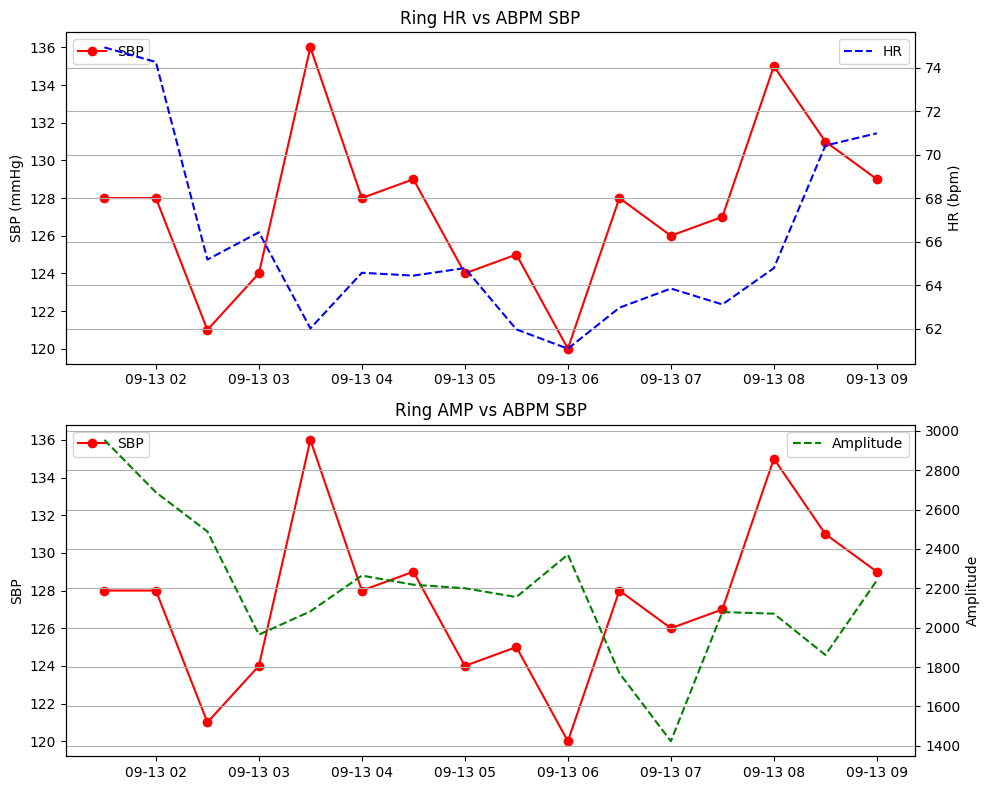

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, detrend, find_peaks

# ============================================================
# CONFIG
# ============================================================
RING_CSV = "/content/drive/MyDrive/Colab Notebooks/RealPPG/ppgRaw2.csv"
RING_FS = 200.0
RING_START_TIME = "2025-09-13 01:24:00"  # 시작 시간 고정

ABPM_XLSX = "/content/drive/MyDrive/Colab Notebooks/PPG_REAL/PWV1.xlsx"

WIN_MIN = 5   # 매칭 윈도우 (분)
MIN_BPM = 40
MAX_BPM = 180

# ============================================================
# FIXED LOAD FUNCTION
# ============================================================
def load_ppg_ring_fixed(csv_path, fs, start_time):
    # 1. CSV 읽기
    try:
        df = pd.read_csv(csv_path)
        # 헤더가 숫자인지 확인 (헤더 없는 경우)
        if len(df.columns) >= 1 and str(df.columns[0]).replace('.','').isdigit():
             df = pd.read_csv(csv_path, header=None)
    except:
        raise ValueError("CSV 로드 실패")

    # 2. PPG 컬럼 찾기 (보통 데이터 많은 쪽, 혹은 2번째)
    # 사용자가 컬럼명을 지정하지 않았으므로 shape 보고 판단
    if df.shape[1] < 2:
        ppg = df.iloc[:, 0].to_numpy(dtype=float) # 컬럼 하나면 그거 씀
    else:
        # 보통 [Time, PPG] 구조이므로 1번 인덱스 사용
        ppg = df.iloc[:, 1].to_numpy(dtype=float)

    # 3. [핵심 수정] 시간축 강제 생성 (CSV 시간 무시)
    # 샘플 개수 기반으로 정확한 시간 배열 생성
    n_samples = len(ppg)
    duration_sec = n_samples / fs

    t_sec = np.arange(n_samples) / fs  # 0.000, 0.005, 0.010 ...

    start_dt = pd.to_datetime(start_time)
    dt = start_dt + pd.to_timedelta(t_sec, unit='s')

    print(f"[Ring Info] Duration: {duration_sec/3600:.2f} hours")

    return pd.Series(dt), ppg

def load_abpm(path):
    df = pd.read_excel(path)
    dt_col = None
    # 날짜 컬럼 찾기 (2000년 이후 데이터만 유효)
    for c in df.columns:
        temp = pd.to_datetime(df[c], errors='coerce')
        if temp.notna().sum() > 3 and (temp.dt.year > 2000).any():
            dt_col = c
            break

    # 병합 컬럼 시도
    if not dt_col:
        cols = list(df.columns)
        for i in range(len(cols)):
            for j in range(len(cols)):
                if i==j: continue
                try:
                    temp = pd.to_datetime(df.iloc[:,i].astype(str)+" "+df.iloc[:,j].astype(str), errors='coerce')
                    if temp.notna().sum() > 3 and (temp.dt.year > 2000).any():
                        dt_col = (cols[i], cols[j])
                        break
                except: pass
            if dt_col: break

    if not dt_col: raise ValueError("ABPM 날짜 컬럼을 못 찾겠습니다.")

    if isinstance(dt_col, tuple):
        df['dt'] = pd.to_datetime(df[dt_col[0]].astype(str)+" "+df[dt_col[1]].astype(str), errors='coerce')
    else:
        df['dt'] = pd.to_datetime(df[dt_col], errors='coerce')

    df = df.dropna(subset=['dt']).sort_values('dt')

    def find_col(keywords):
        for k in keywords:
            for c in df.columns:
                if k.lower() in str(c).lower(): return c
        return None

    cols = {
        'SBP': find_col(['sbp', 'sys']),
        'DBP': find_col(['dbp', 'dia']),
        'MAP': find_col(['map', 'mean'])
    }

    out = df[['dt'] + [v for v in cols.values() if v]].copy()
    out = out.rename(columns={v:k for k,v in cols.items() if v})
    return out

def extract_features(dt, ppg, fs):
    # 전처리
    ppg = np.nan_to_num(ppg)
    ppg = detrend(ppg)
    # Bandpass Filter (0.5 ~ 8 Hz)
    nyq = 0.5 * fs
    b, a = butter(2, [0.5/nyq, 8/nyq], btype='band')
    y = filtfilt(b, a, ppg)

    # Peak Detection
    # 윈도우 크기 설정 (심박수 고려)
    dist = int(fs * 0.3) # 0.3초 (최대 200bpm)
    peaks, _ = find_peaks(y, distance=dist, prominence=np.std(y)*0.5)
    troughs, _ = find_peaks(-y, distance=dist)

    beats = []
    t_sec = np.arange(len(y)) / fs

    # 피크-피크 분석
    peaks = peaks[peaks > troughs[0]] if len(troughs) > 0 and len(peaks) > 0 else peaks

    for i in range(len(peaks)-1):
        idx = peaks[i]
        next_idx = peaks[i+1]

        # 유효한 Trough (피크 직전)
        tr_candidates = troughs[troughs < idx]
        if len(tr_candidates) == 0: continue
        tr_idx = tr_candidates[-1]

        # Features
        ppi = t_sec[next_idx] - t_sec[idx]
        hr = 60.0 / ppi
        amp = y[idx] - y[tr_idx]

        if hr < MIN_BPM or hr > MAX_BPM: continue

        beats.append({
            'dt': dt.iloc[idx],
            'HR': hr,
            'AMP': amp
        })

    return pd.DataFrame(beats)

# ============================================================
# MAIN
# ============================================================
print("="*60)
print("Ring (200Hz) vs ABPM Direct Analysis")
print("="*60)

# 1. Load Ring
print("Loading Ring Data...")
dt_ring, ppg_ring = load_ppg_ring_fixed(RING_CSV, RING_FS, RING_START_TIME)
print(f"Ring Range: {dt_ring.min()} ~ {dt_ring.max()}")

# 2. Load ABPM
print("\nLoading ABPM Data...")
abpm_df = load_abpm(ABPM_XLSX)
print(f"ABPM Range: {abpm_df['dt'].min()} ~ {abpm_df['dt'].max()} (n={len(abpm_df)})")

# 3. Common Period Crop
start = max(dt_ring.min(), abpm_df['dt'].min())
end = min(dt_ring.max(), abpm_df['dt'].max())

print(f"\n[Common Period] {start} ~ {end}")

duration = (end - start).total_seconds()
if duration <= 0:
    print("⚠ 겹치는 시간대가 없습니다! 시작시간이나 데이터를 확인해주세요.")
else:
    # Crop Ring Data
    mask = (dt_ring >= start) & (dt_ring <= end)
    dt_cut = dt_ring[mask].reset_index(drop=True)
    ppg_cut = ppg_ring[mask]

    # Crop ABPM Data
    abpm_cut = abpm_df[(abpm_df['dt'] >= start) & (abpm_df['dt'] <= end)].reset_index(drop=True)

    print(f"Analyzing {len(dt_cut)} samples ({duration/3600:.1f} hours)...")

    # 4. Feature Extraction
    beats_df = extract_features(dt_cut, ppg_cut, RING_FS)
    print(f"Extracted {len(beats_df)} beats.")

    if len(beats_df) > 0:
        # 5. Matching
        results = []
        for idx, row in abpm_cut.iterrows():
            t = row['dt']
            # ABPM 시간 기준 ±WIN_MIN 분
            sub = beats_df[(beats_df['dt'] >= t - pd.Timedelta(minutes=WIN_MIN)) &
                           (beats_df['dt'] <= t + pd.Timedelta(minutes=WIN_MIN))]

            if len(sub) > 10: # 최소 10비트 이상 있어야 평균 인정
                res = {
                    'dt': t,
                    'SBP': row['SBP'] if 'SBP' in row else np.nan,
                    'DBP': row['DBP'] if 'DBP' in row else np.nan,
                    'HR_Ring': sub['HR'].mean(),
                    'AMP_Ring': sub['AMP'].mean()
                }
                results.append(res)

        final_df = pd.DataFrame(results)

        # 6. Report
        if len(final_df) > 0:
            print(f"\nMatched {len(final_df)} events!")
            print(final_df.head())

            # Correlation
            print("\n[Correlations]")
            if 'SBP' in final_df.columns:
                print(f"HR vs SBP: r = {final_df['HR_Ring'].corr(final_df['SBP']):.3f}")
                print(f"AMP vs SBP: r = {final_df['AMP_Ring'].corr(final_df['SBP']):.3f}")

            # Plot
            plt.figure(figsize=(10, 8))

            plt.subplot(2,1,1)
            plt.title("Ring HR vs ABPM SBP")
            plt.plot(final_df['dt'], final_df['SBP'], 'r-o', label='SBP')
            plt.ylabel("SBP (mmHg)")
            plt.legend(loc='upper left')
            ax2 = plt.twinx()
            ax2.plot(final_df['dt'], final_df['HR_Ring'], 'b--', label='HR')
            ax2.set_ylabel("HR (bpm)")
            ax2.legend(loc='upper right')
            plt.grid()

            plt.subplot(2,1,2)
            plt.title("Ring AMP vs ABPM SBP")
            plt.plot(final_df['dt'], final_df['SBP'], 'r-o', label='SBP')
            plt.ylabel("SBP")
            plt.legend(loc='upper left')
            ax3 = plt.twinx()
            ax3.plot(final_df['dt'], final_df['AMP_Ring'], 'g--', label='Amplitude')
            ax3.set_ylabel("Amplitude")
            ax3.legend(loc='upper right')
            plt.grid()

            plt.tight_layout()
            plt.show()

        else:
            print("매칭된 구간에 유효한 비트가 없습니다. (노이즈가 심하거나 데이터가 비어있음)")
    else:
        print("비트 추출 실패. 신호 품질을 확인하세요.")